# 🏥 Health Care Premium Prediction — Full Pipeline

## Project Overview

This notebook builds an end-to-end **machine learning regression pipeline** to predict the **annual health insurance premium** of a customer based on lifestyle, demographic, and medical factors.

The pipeline covers:

1. **Data Loading & Column Cleaning**
2. **Exploratory Data Analysis (EDA)** — missing values, distributions, outliers
3. **Outlier Removal**
4. **Categorical Encoding** — ordinal + one-hot
5. **Feature Engineering** — medical risk score
6. **Feature Scaling & Multicollinearity Check (VIF)**
7. **Model Training** — Linear Regression, Ridge, Random Forest, XGBoost
8. **Model Evaluation** — R², residual analysis
9. **Artifact Saving** — model and scaler persisted to disk

---

### Dataset at a Glance

| Column | Description |
|---|---|
| `age` | Age of the insured |
| `gender` | Male / Female |
| `region` | Geographic region |
| `marital_status` | Married / Unmarried |
| `physical_activity` | Low / Medium / High |
| `stress_level` | Low / Medium / High |
| `number_of_dependants` | Number of dependants covered |
| `bmi_category` | Normal / Overweight / Obesity / Underweight |
| `smoking_status` | No Smoking / Occasional / Regular |
| `employment_status` | Salaried / Self-Employed / Freelancer |
| `income_level` | Bucketed income range |
| `income_lakhs` | Income in lakhs (numeric) |
| `medical_history` | Disease conditions (can be compound, e.g. `Diabetes & Thyroid`) |
| `insurance_plan` | Bronze / Silver / Gold |
| `annual_premium_amount` | **Target variable** — premium in INR |


---
## Section 1 — Library Imports

We import all libraries upfront. Key packages and their roles:

- **`numpy` / `pandas`** — data manipulation
- **`matplotlib` / `seaborn`** — visualizations
- **`StandardScaler`** — feature normalization
- **`variance_inflation_factor`** — multicollinearity detection
- **`train_test_split`** — splitting data into train/test
- **`LinearRegression`, `Ridge`** — linear models (baseline)
- **`RandomForestRegressor`** — ensemble tree model
- **`XGBRegressor`** — gradient boosting (typically strongest for tabular data)
- **`RandomizedSearchCV`** — hyperparameter tuning
- **`joblib.dump`** — saving trained model objects to disk

> ⚠️ **Note:** `seaborn` is imported twice — this is a minor redundancy, but harmless.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
import math
import textwrap
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from joblib import dump

---
## Section 2 — Data Loading & Initial Cleaning

### 2.1 Load the Dataset

The dataset is stored as an Excel file (`premiums_with_life_style.xlsx`) and loaded with `pd.read_excel()`.

In [2]:
df = pd.read_excel("premiums_with_life_style.xlsx")

### 2.2 Column Name Standardization

Column names are normalized to **snake_case** (lowercase + underscores instead of spaces).  
This prevents bugs from column names with spaces, e.g. `df['Annual Premium Amount']` vs `df['annual_premium_amount']`.

Two operations chained:
- `.str.replace(' ', '_')` — replaces spaces
- `.str.lower()` — converts to lowercase

In [3]:
df.columns = df.columns.str.replace(' ', '_').str.lower()

### 2.3 Preview the Data

`.head()` shows the first 5 rows — useful to confirm the schema and spot obvious issues at a glance.

In [4]:
df.head()

,age,gender,region,marital_status,physical_activity,stress_level,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,56,Female,Southeast,Unmarried,Medium,Medium,2,Normal,No Smoking,Self-Employed,25L - 40L,37,High blood pressure,Gold,27944
1,38,Female,Northeast,Married,Low,High,5,Overweight,Occasional,Freelancer,10L - 25L,10,No Disease,Silver,21108
2,18,Female,Southwest,Unmarried,Medium,High,0,Normal,No Smoking,Freelancer,<10L,9,No Disease,Bronze,8459
3,55,Male,Northeast,Married,High,Medium,3,Overweight,Occasional,Salaried,<10L,9,Thyroid,Silver,21685
4,22,Male,Southeast,Unmarried,Medium,High,2,Normal,Regular,Self-Employed,10L - 25L,13,High blood pressure & Heart disease,Bronze,15984


---
## Section 3 — Missing Value Analysis

### 3.1 Check for Nulls

`df.isna().sum()` counts missing values per column. From the output, we see:

| Column | Missing |
|---|---|
| `smoking_status` | 9 |
| `employment_status` | 7 |
| `income_level` | 18 |
| All others | 0 |

Total missing rows: **~34**, which is very small relative to ~10,000 rows (<0.4%). Safe to drop.

In [5]:
df.isna().sum()

age                       0
gender                    0
region                    0
marital_status            0
physical_activity         0
stress_level              0
number_of_dependants      0
bmi_category              0
smoking_status            9
employment_status         7
income_level             18
income_lakhs              0
medical_history           0
insurance_plan            0
annual_premium_amount     0
dtype: int64

### 3.2 Visualize Missing Values

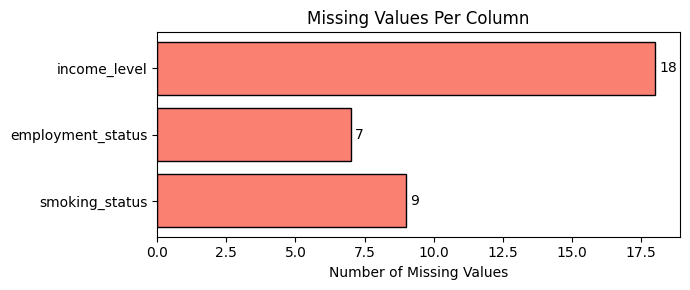

In [6]:
# Visualization: Missing value bar chart
missing = df.isna().sum()
missing = missing[missing > 0]

fig, ax = plt.subplots(figsize=(7, 3))
bars = ax.barh(missing.index, missing.values, color='salmon', edgecolor='black')
ax.bar_label(bars, padding=3)
ax.set_xlabel('Number of Missing Values')
ax.set_title('Missing Values Per Column')
plt.tight_layout()
plt.show()

### 3.3 Drop Rows with Missing Values

`df.dropna()` removes all rows that have **at least one null value**.  
Since only ~34 rows are affected (<0.4% of data), this is a safe and simple strategy.  
Imputation wasn't needed here, but for larger proportions of missing data, you'd want to consider mean/mode imputation or model-based imputation.

In [7]:
df = df.dropna()
print(f"Rows after dropping nulls: {df.shape[0]}")

Rows after dropping nulls: 9973


---
## Section 4 — Exploratory Data Analysis (EDA)

### 4.1 Summary Statistics

`.describe()` shows count, mean, std, min, quartiles, and max for numeric columns.  

**Key observations:**
- `age` max = **1178** → clearly a data entry error (a human can't be 1178 years old)
- `number_of_dependants` max = **456** → another extreme outlier
- `income_lakhs` max = **960** → also suspicious; we'll filter at 100L
- `annual_premium_amount` range: ₹3,582 — ₹45,854 → reasonable range for Indian health insurance

In [8]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,9973.000000,9973.000000,9973.000000,9973.000000
mean,41.319362,3.195628,23.382232,19503.816705
std,58.044687,21.679565,32.334811,8898.079736
min,18.000000,0.000000,1.000000,3582.000000
25%,24.000000,0.000000,6.000000,11774.000000
50%,37.000000,2.000000,16.000000,19314.000000
75%,50.000000,3.000000,31.000000,26500.000000
max,1178.000000,456.000000,960.000000,45854.000000


### 4.2 Outlier Detection — Boxplots

Boxplots visually reveal outliers as individual points beyond the whiskers.  
The plot below shows boxplots for all 4 numeric columns (`age`, `number_of_dependants`, `income_lakhs`, `annual_premium_amount`).

The extreme outliers in `age` and `number_of_dependants` will be clearly visible.

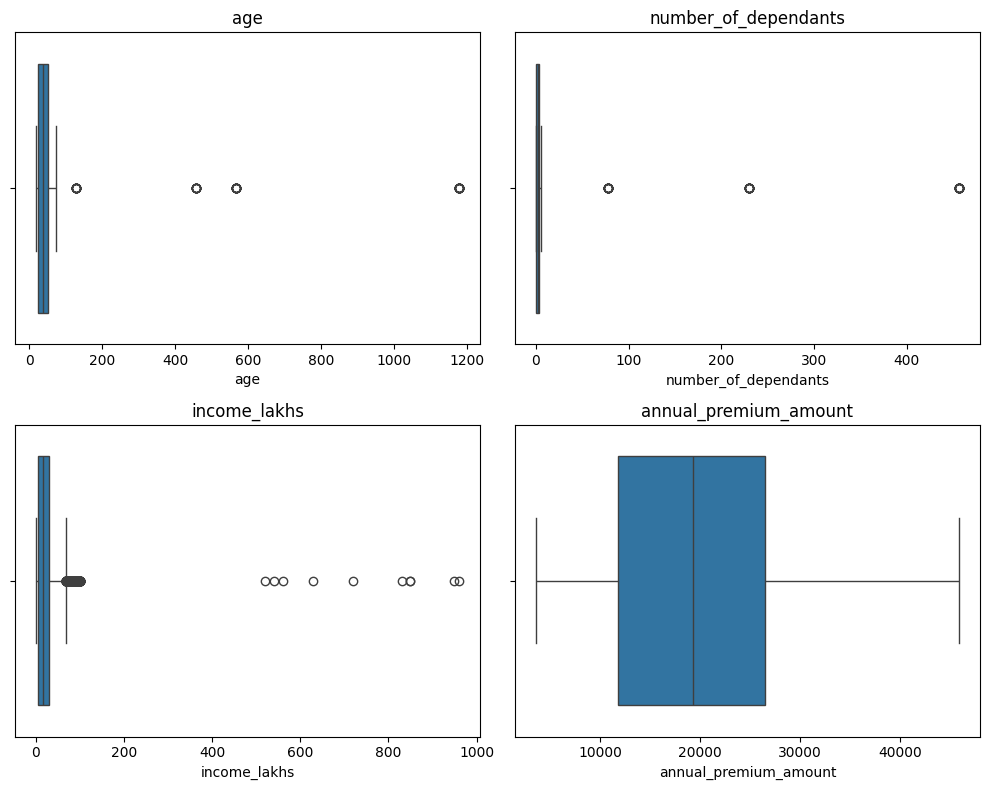

In [9]:
numeric_df = df.select_dtypes(['float64', 'int64'])

cols = numeric_df.columns[:4]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(x=numeric_df[col], ax=axes[i])
    axes[i].set_title(col)

for j in range(len(cols), 4):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

---
## Section 5 — Outlier Removal

### 5.1 Filter by Age

We keep only rows where `age <= 100`. This removes data entry errors like age 1178.  
This creates a **copy** (`df1`) rather than modifying in-place, which is good practice.

In [10]:
df1 = df[df.age <= 100].copy()
print(f"Rows after age filter: {df1.shape[0]}")

Rows after age filter: 9915


### 5.2 Verify Age Filter

In [11]:
df1.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,9915.000000,9915.000000,9915.000000,9915.000000
mean,37.743621,3.203429,23.400807,19496.715784
std,13.975462,21.742340,32.398236,8899.088302
min,18.000000,0.000000,1.000000,3582.000000
25%,24.000000,0.000000,6.000000,11765.500000
50%,37.000000,2.000000,16.000000,19309.000000
75%,50.000000,3.000000,31.000000,26493.000000
max,72.000000,456.000000,960.000000,45854.000000


### 5.3 Filter by Income

We further filter `income_lakhs <= 100`. The earlier max of 960L was unrealistic.  
100L (₹1 Crore annual income) is a reasonable ceiling for the target population of health insurance policyholders.

In [12]:
df2 = df1[df1.income_lakhs <= 100].copy()
print(f"Rows after income filter: {df2.shape[0]}")

Rows after income filter: 9905


### 5.4 Drop `income_level` Column

`income_level` is a **bucketed string version** of `income_lakhs` (e.g., '10L - 25L').  
Since we already have the numeric `income_lakhs`, `income_level` is **redundant** — keeping it would create multicollinearity.  
Drop it and confirm via `.describe()`.

In [13]:
df2.drop("income_level", axis=1, inplace=True)
df2.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,9905.000000,9905.000000,9905.000000,9905.000000
mean,37.751843,3.205553,22.676325,19499.125088
std,13.974916,21.753158,22.453983,8898.743837
min,18.000000,0.000000,1.000000,3582.000000
25%,24.000000,0.000000,6.000000,11767.000000
50%,37.000000,2.000000,16.000000,19314.000000
75%,50.000000,3.000000,31.000000,26493.000000
max,72.000000,456.000000,100.000000,45854.000000


### 5.5 Visualize Distributions After Cleaning

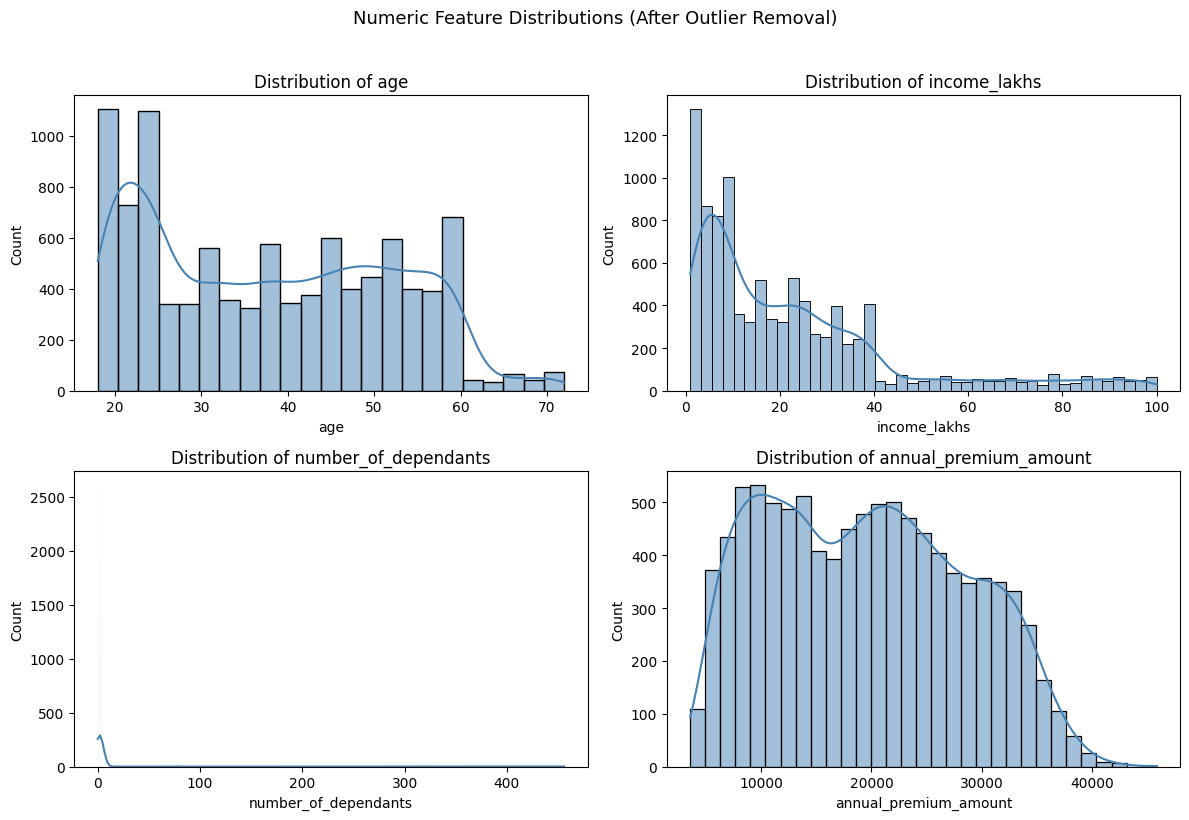

In [14]:
# Distribution plots for cleaned numeric columns
num_cols = ['age', 'income_lakhs', 'number_of_dependants', 'annual_premium_amount']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df2[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)

plt.suptitle('Numeric Feature Distributions (After Outlier Removal)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 5.6 Explore Categorical Variables

We loop through all categorical columns to see their unique values and frequency counts.  
This informs which encoding strategy to use (ordinal vs. one-hot).

In [15]:
categorical_df = df2.select_dtypes(include=['object', 'category'])

for col in categorical_df.columns:
    print(f"{col}: {categorical_df[col].unique()}\n")
    print(f"{col}:\n{categorical_df[col].value_counts()}\n")

gender: ['Female' 'Male']

gender:
gender
Female    5933
Male      3972
Name: count, dtype: int64

region: ['Southeast' 'Northeast' 'Southwest' 'Northwest']

region:
region
Southeast    3498
Southwest    3035
Northwest    1929
Northeast    1443
Name: count, dtype: int64

marital_status: ['Unmarried' 'Married']

marital_status:
marital_status
Married      5568
Unmarried    4337
Name: count, dtype: int64

physical_activity: ['Medium' 'Low' 'High']

physical_activity:
physical_activity
Medium    5440
Low       2494
High      1971
Name: count, dtype: int64

stress_level: ['Medium' 'High' 'Low']

stress_level:
stress_level
Medium    4936
High      2994
Low       1975
Name: count, dtype: int64

bmi_category: ['Normal' 'Overweight' 'Obesity' 'Underweight']

bmi_category:
bmi_category
Normal         4454
Overweight     2383
Obesity        1663
Underweight    1405
Name: count, dtype: int64

smoking_status: ['No Smoking' 'Occasional' 'Regular']

smoking_status:
smoking_status
No Smoking    5664


### 5.7 Visualize Categorical Distributions

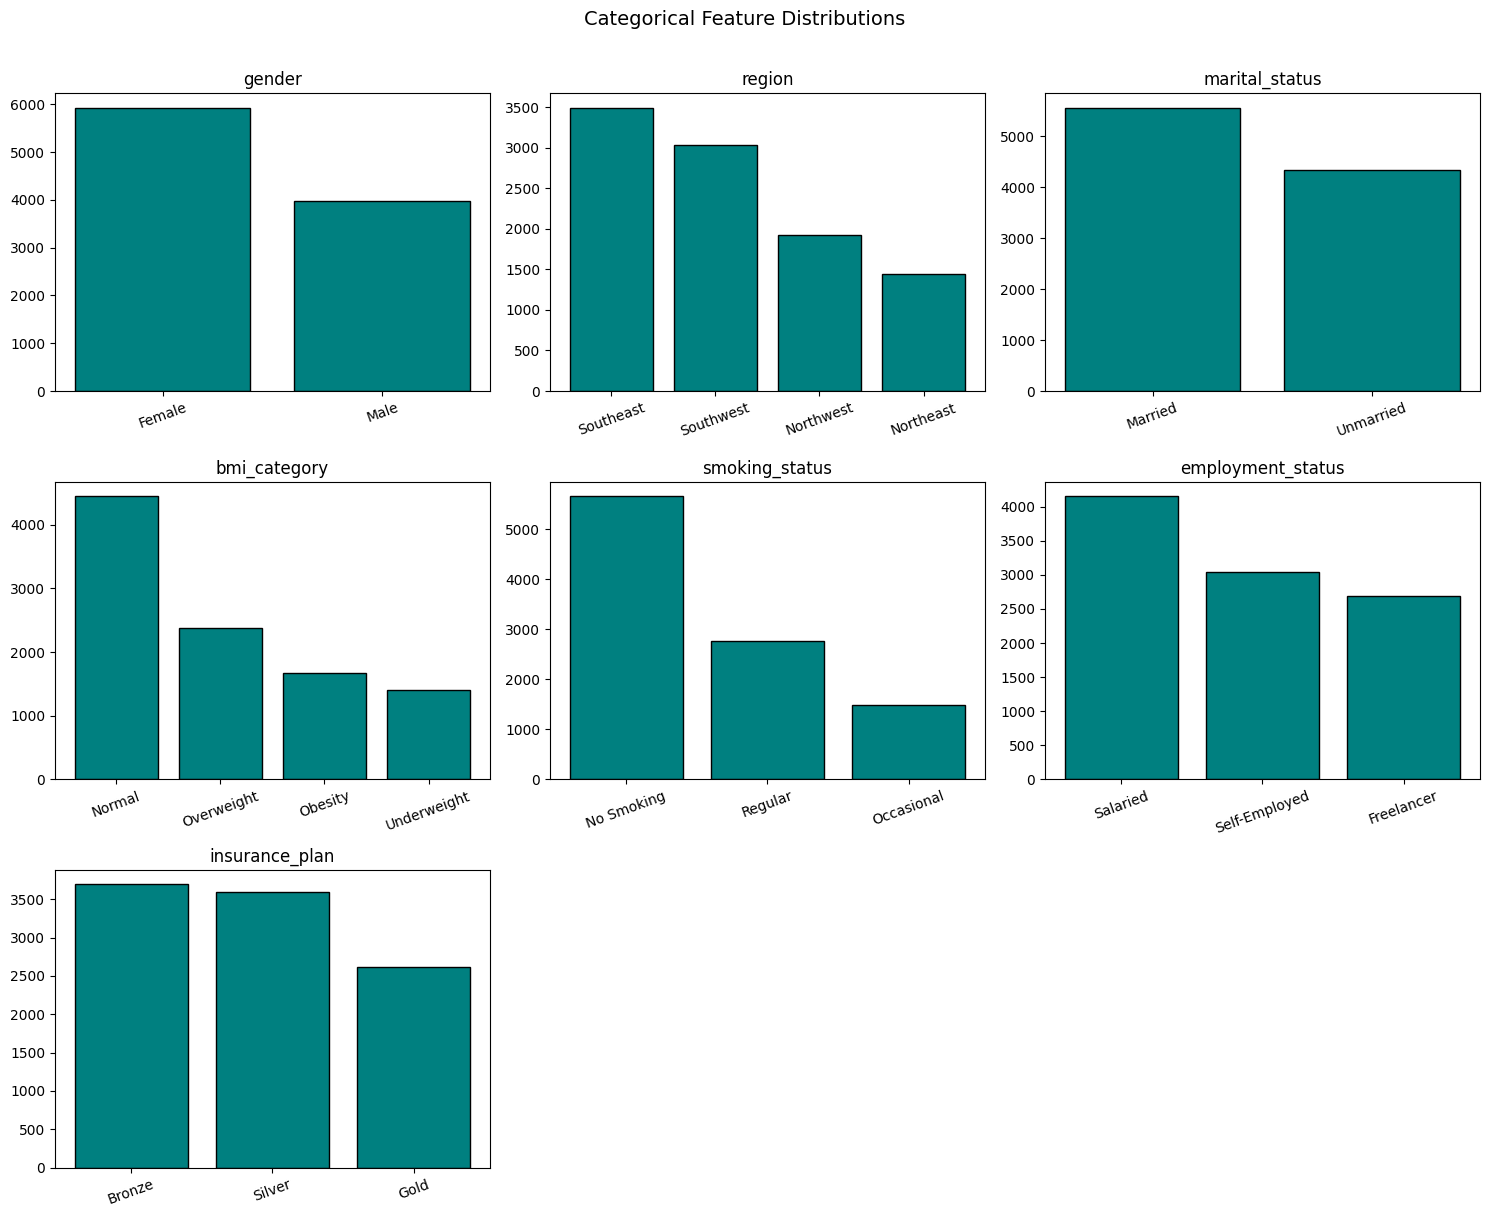

In [16]:
cat_cols = ['gender', 'region', 'marital_status', 'bmi_category',
            'smoking_status', 'employment_status', 'insurance_plan']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    vc = df2[col].value_counts()
    axes[i].bar(vc.index, vc.values, color='teal', edgecolor='black')
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=20)

for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Categorical Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## Section 6 — Categorical Encoding

### 6.1 Ordinal Encoding (Manual `.map()`)

Columns with a **natural order** are encoded as integers, preserving that ordering:

| Column | Mapping |
|---|---|
| `gender` | Female → 0, Male → 1 |
| `marital_status` | Unmarried → 0, Married → 1 |
| `physical_activity` | Low → 0, Medium → 1, High → 2 |
| `stress_level` | Low → 0, Medium → 1, High → 2 |
| `smoking_status` | Regular → 0, Occasional → 1, No Smoking → 2 |
| `insurance_plan` | Bronze → 0, Silver → 1, Gold → 2 |

> ⚠️ **Design note:** `smoking_status` is encoded with Regular=0 (highest risk) and No Smoking=2 (lowest risk). This is intentional — it makes the ordinal direction consistent with risk level.

In [17]:
df2["gender"]            = df2["gender"].map({"Female": 0, "Male": 1})
df2["marital_status"]    = df2["marital_status"].map({"Unmarried": 0, "Married": 1})
df2["physical_activity"] = df2["physical_activity"].map({"Low": 0, "Medium": 1, "High": 2})
df2["stress_level"]      = df2["stress_level"].map({"Low": 0, "Medium": 1, "High": 2})
df2["smoking_status"]    = df2["smoking_status"].map({"Regular": 0, "Occasional": 1, "No Smoking": 2})
df2["insurance_plan"]    = df2["insurance_plan"].map({"Bronze": 0, "Silver": 1, "Gold": 2})

**Confirm the mappings look correct:**

In [18]:
df2.head()

,age,gender,region,marital_status,physical_activity,stress_level,number_of_dependants,bmi_category,smoking_status,employment_status,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,56,0,Southeast,0,1,1,2,Normal,2,Self-Employed,37,High blood pressure,2,27944
1,38,0,Northeast,1,0,2,5,Overweight,1,Freelancer,10,No Disease,1,21108
2,18,0,Southwest,0,1,2,0,Normal,2,Freelancer,9,No Disease,0,8459
3,55,1,Northeast,1,2,1,3,Overweight,1,Salaried,9,Thyroid,1,21685
4,22,1,Southeast,0,1,2,2,Normal,0,Self-Employed,13,High blood pressure & Heart disease,0,15984


---
## Section 7 — Feature Engineering: Medical Risk Score

### 7.1 Define Risk Scores

The `medical_history` column contains values like `"Diabetes & Heart disease"` — a compound string.  
Rather than one-hot encoding dozens of combinations, we **engineer a numeric risk score** by assigning severity weights to each disease:

| Disease | Risk Score |
|---|---|
| Heart Disease | 8 |
| Diabetes | 6 |
| High Blood Pressure | 6 |
| Thyroid | 5 |
| No Disease / None | 0 |

These scores are **domain-inspired heuristics** (not derived from data). A patient with both Diabetes and Heart Disease would score 6+8=14.

In [19]:
risk_scores = {
    'diabetes': 6,
    'heart disease': 8,
    'high blood pressure': 6,
    'thyroid': 5,
    'no disease': 0,
    'none': 0
}

### 7.2 Split Medical History Into Two Disease Columns

`medical_history` values can be single diseases (e.g., `"Diabetes"`) or compound (e.g., `"Diabetes & Thyroid"`).  
We split on `' & '` to produce two columns: `disease1` and `disease2`.  
Single-disease rows will have `NaN` in `disease2`, which is handled next.

In [20]:
df2[['disease1', 'disease2']] = (
    df2['medical_history']
    .str.split(' & ', expand=True)
    .apply(lambda x: x.str.lower())
)

### 7.3 Compute Total Risk Score

1. Initialize `total_risk_score = 0`
2. Fill NaN in `disease1`/`disease2` with `'none'` (score = 0)
3. Map each disease to its score, accumulate for both disease columns

This single numeric feature replaces the complex multi-value `medical_history` string column.

In [21]:
df2['total_risk_score'] = 0

df2['disease1'] = df2['disease1'].fillna('none')
df2['disease2'] = df2['disease2'].fillna('none')

for disease in ['disease1', 'disease2']:
    df2['total_risk_score'] += df2[disease].map(risk_scores).fillna(0)

### 7.4 Drop Intermediate Columns

The temporary `disease1`, `disease2`, and original `medical_history` columns are no longer needed.

In [22]:
df2.drop(['disease1', 'disease2', 'medical_history'], axis=1, inplace=True)

### 7.5 Confirm New Feature

In [23]:
df2.head()

,age,gender,region,marital_status,physical_activity,stress_level,number_of_dependants,bmi_category,smoking_status,employment_status,income_lakhs,insurance_plan,annual_premium_amount,total_risk_score
0,56,0,Southeast,0,1,1,2,Normal,2,Self-Employed,37,2,27944,6
1,38,0,Northeast,1,0,2,5,Overweight,1,Freelancer,10,1,21108,0
2,18,0,Southwest,0,1,2,0,Normal,2,Freelancer,9,0,8459,0
3,55,1,Northeast,1,2,1,3,Overweight,1,Salaried,9,1,21685,5
4,22,1,Southeast,0,1,2,2,Normal,0,Self-Employed,13,0,15984,14


### 7.6 Risk Score Distribution

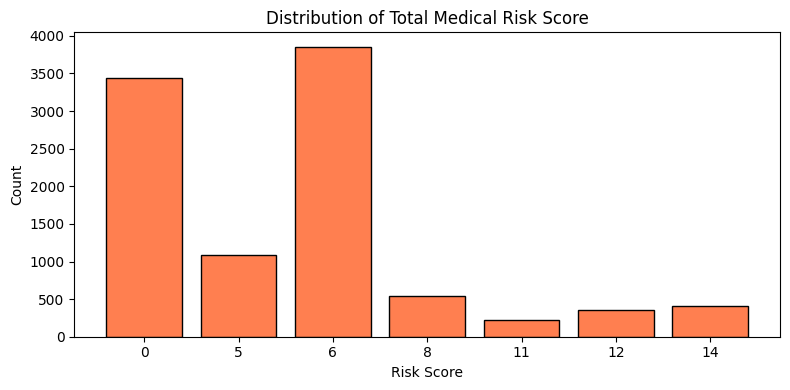

In [24]:
fig, ax = plt.subplots(figsize=(8, 4))
vc = df2['total_risk_score'].value_counts().sort_index()
ax.bar(vc.index.astype(str), vc.values, color='coral', edgecolor='black')
ax.set_title('Distribution of Total Medical Risk Score')
ax.set_xlabel('Risk Score')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

---
## Section 8 — One-Hot Encoding (Nominal Columns)

For columns **without a natural order** (`region`, `bmi_category`, `employment_status`), we use **one-hot encoding** via `pd.get_dummies()`.

- `drop_first=True` drops one category per column to avoid the **dummy variable trap** (perfect multicollinearity between dummies).
  - e.g., `region` has 4 values → creates 3 binary columns; the 4th (Northeast) is the implicit baseline
- `dtype=int` stores the dummies as 0/1 integers instead of booleans

In [25]:
normal_columns = ['region', 'bmi_category', 'employment_status']

df3 = pd.get_dummies(
    df2,
    columns=normal_columns,
    drop_first=True,
    dtype=int
)
df3.head()

,age,gender,marital_status,physical_activity,stress_level,number_of_dependants,smoking_status,income_lakhs,insurance_plan,annual_premium_amount,total_risk_score,region_Northwest,region_Southeast,region_Southwest,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,employment_status_Salaried,employment_status_Self-Employed
0,56,0,0,1,1,2,2,37,2,27944,6,0,1,0,0,0,0,0,1
1,38,0,1,0,2,5,1,10,1,21108,0,0,0,0,0,1,0,0,0
2,18,0,0,1,2,0,2,9,0,8459,0,0,0,1,0,0,0,0,0
3,55,1,1,2,1,3,1,9,1,21685,5,0,0,0,0,1,0,1,0
4,22,1,0,1,2,2,0,13,0,15984,14,0,1,0,0,0,0,0,1


---
## Section 9 — Feature Scaling

### 9.1 Define X and y

- `X` = all features except `annual_premium_amount`
- `y` = target: `annual_premium_amount`

### 9.2 StandardScaler

`StandardScaler` transforms each feature to have **mean = 0** and **std = 1**:  
`z = (x - mean) / std`

**Why scale?**
- Linear models are sensitive to feature scale — an unscaled `income_lakhs` (range 1–100) would dominate `gender` (0 or 1)
- Also required for VIF calculation to work correctly
- Tree-based models (RF, XGBoost) don't technically need scaling, but it doesn't hurt

The scaler is fitted **only on X** (not y), and `fit_transform` is applied to get `X_scaled`.  
We then rebuild it back into a DataFrame to keep column names.

In [1]:
X = df3.drop("annual_premium_amount", axis=1)
y = df3["annual_premium_amount"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

NameError: name 'df3' is not defined

---
## Section 10 — Multicollinearity Check (VIF)

**Variance Inflation Factor (VIF)** measures how much the variance of a regression coefficient is inflated due to multicollinearity with other features.

| VIF Value | Interpretation |
|---|---|
| 1 | No correlation |
| 1–5 | Moderate, acceptable |
| > 5–10 | High — consider removing |

All VIF values here are **below 2.5**, indicating no significant multicollinearity. The features are well-separated from each other.

In [27]:
def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df['Variable'] = data.columns
    vif_df['VIF'] = [variance_inflation_factor(data.values, i) for i in range(data.shape[1])]
    return vif_df

In [28]:
vif_result = calculate_vif(X)
vif_result

,Variable,VIF
0,age,1.957928
1,gender,1.140072
2,marital_status,1.477409
3,physical_activity,1.001671
4,stress_level,1.002074
5,number_of_dependants,1.004619
6,smoking_status,1.143296
7,income_lakhs,1.287862
8,insurance_plan,1.705025
9,total_risk_score,1.295669


### 10.1 Visualize VIF Scores

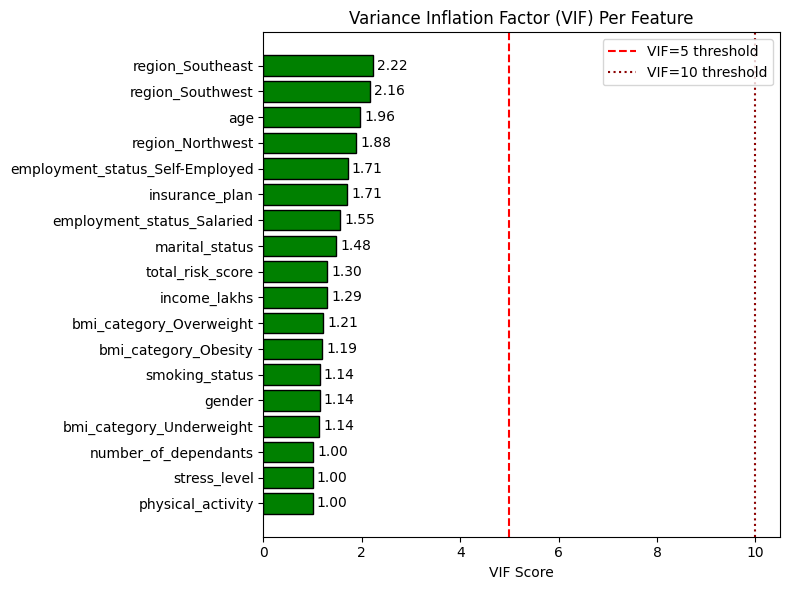

In [29]:
vif_result_sorted = vif_result.sort_values('VIF', ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['green' if v < 5 else 'red' for v in vif_result_sorted['VIF']]
bars = ax.barh(vif_result_sorted['Variable'], vif_result_sorted['VIF'], color=colors, edgecolor='black')
ax.axvline(x=5, color='red', linestyle='--', label='VIF=5 threshold')
ax.axvline(x=10, color='darkred', linestyle=':', label='VIF=10 threshold')
ax.bar_label(bars, fmt='%.2f', padding=3)
ax.set_xlabel('VIF Score')
ax.set_title('Variance Inflation Factor (VIF) Per Feature')
ax.legend()
plt.tight_layout()
plt.show()

---
## Section 11 — Train/Test Split

`train_test_split` splits the data into 70% training and 30% test sets.  

**Important:** No `random_state` is set here, which means results will vary slightly across runs. For reproducibility, you'd want `random_state=42` (or any fixed integer).

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")

Training samples : 6933
Test samples     : 2972


---
## Section 12 — Model Training

Four models are trained — progressing from simple to complex:

### 12.1 Linear Regression (Baseline)

Ordinary Least Squares — fits a hyperplane through the data.  
- Simple, interpretable
- Assumes linear relationships and no strong interactions between features
- `.score()` returns **R²** (coefficient of determination):  
  R² = 1 means perfect prediction; R² = 0 means the model is no better than predicting the mean

In [31]:
lr = LinearRegression()
lr.fit(X_train, y_train)
print(f"Linear Regression — Test R²  : {lr.score(X_test, y_test):.4f}")
print(f"Linear Regression — Train R² : {lr.score(X_train, y_train):.4f}")

Linear Regression — Test R²  : 0.9560
Linear Regression — Train R² : 0.9554


### 12.2 Ridge Regression

Ridge adds **L2 regularization** — it penalizes large coefficients, which helps with overfitting.  
`alpha=15` is the regularization strength (higher α = more shrinkage).  

If Linear and Ridge give similar R², that confirms there's no serious overfitting issue with OLS here.

In [32]:
from sklearn.linear_model import Ridge
ridge_model = Ridge(alpha=15)
ridge_model.fit(X_train, y_train)
print(f"Ridge — Test R²  : {ridge_model.score(X_test, y_test):.4f}")
print(f"Ridge — Train R² : {ridge_model.score(X_train, y_train):.4f}")

Ridge — Test R²  : 0.9559
Ridge — Train R² : 0.9554


### 12.3 Random Forest with RandomizedSearchCV

Random Forest is an **ensemble of decision trees** — each tree is trained on a bootstrapped sample with a random subset of features.  

**RandomizedSearchCV** performs hyperparameter tuning by:
- Sampling `n_iter=10` random parameter combinations from `rf_param_dist`
- Using 3-fold cross-validation (`cv=3`) on the training set
- Scoring with `R²`

Key hyperparameters tuned:

| Param | Values tried | Effect |
|---|---|---|
| `n_estimators` | 100, 200, 300 | More trees → better accuracy but slower |
| `max_depth` | None, 10, 20 | Controls overfitting |
| `min_samples_split` | 2, 5 | Min samples to split a node |
| `min_samples_leaf` | 1, 2 | Min samples at a leaf |
| `max_features` | sqrt, log2 | Features considered at each split |

In [33]:
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

rf_param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2"]
}

rf_search = RandomizedSearchCV(
    rf,
    param_distributions=rf_param_dist,
    n_iter=10,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rf_search.fit(X_train, y_train)

print(f"Best params : {rf_search.best_params_}")
print(f"Best CV R²  : {rf_search.best_score_:.4f}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best params : {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20}
Best CV R²  : 0.9778


### 12.4 XGBoost with RandomizedSearchCV

XGBoost builds trees **sequentially**, each correcting the errors of the previous one (gradient boosting).  
It often outperforms Random Forest on tabular data.

`tree_method='hist'` uses a histogram-based algorithm — faster than the default, especially on large datasets.

Key hyperparameters tuned:

| Param | Values tried | Effect |
|---|---|---|
| `n_estimators` | 100–300 | Number of boosting rounds |
| `learning_rate` | 0.05–0.2 | Shrinks contribution of each tree (lower = more robust, needs more trees) |
| `max_depth` | 3–7 | Tree depth — higher = more complex |
| `subsample` | 0.7–0.9 | Fraction of rows per tree (prevents overfitting) |
| `colsample_bytree` | 0.7–0.9 | Fraction of features per tree |
| `reg_lambda` | 1–2 | L2 regularization on weights |

In [34]:
xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

xgb_param_dist = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.05, 0.1, 0.2],
    "max_depth": [3, 5, 7],
    "subsample": [0.7, 0.9],
    "colsample_bytree": [0.7, 0.9],
    "reg_lambda": [1, 2]
}

xgb_search = RandomizedSearchCV(
    xgb,
    param_distributions=xgb_param_dist,
    n_iter=15,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

xgb_search.fit(X_train, y_train)

print(f"Best params : {xgb_search.best_params_}")
print(f"Best CV R²  : {xgb_search.best_score_:.4f}")

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best params : {'subsample': 0.7, 'reg_lambda': 2, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.2, 'colsample_bytree': 0.9}
Best CV R²  : 0.9944


### 12.5 Model Comparison Summary

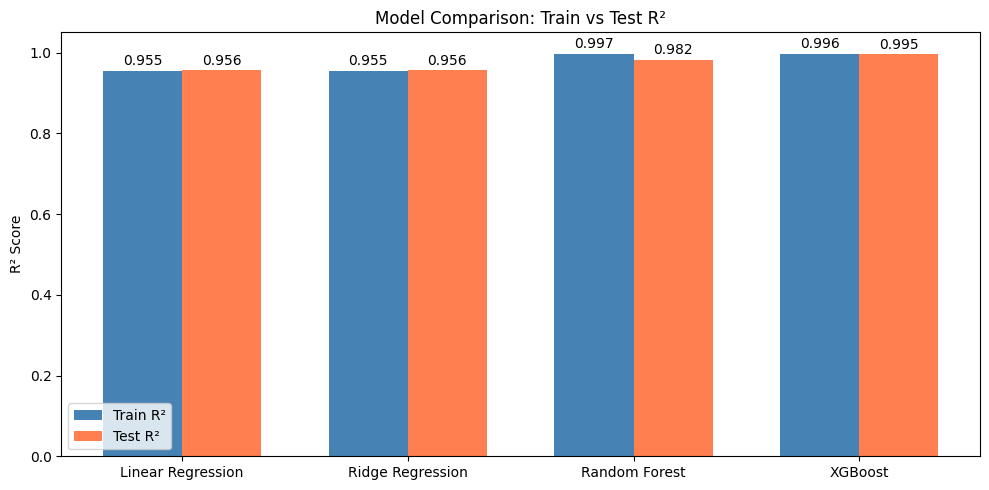

In [35]:
model_scores = {
    'Linear Regression': (lr.score(X_train, y_train), lr.score(X_test, y_test)),
    'Ridge Regression':  (ridge_model.score(X_train, y_train), ridge_model.score(X_test, y_test)),
    'Random Forest':     (rf_search.best_estimator_.score(X_train, y_train),
                          rf_search.best_estimator_.score(X_test, y_test)),
    'XGBoost':           (xgb_search.best_estimator_.score(X_train, y_train),
                          xgb_search.best_estimator_.score(X_test, y_test)),
}

models     = list(model_scores.keys())
train_r2   = [v[0] for v in model_scores.values()]
test_r2    = [v[1] for v in model_scores.values()]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - width/2, train_r2, width, label='Train R²', color='steelblue')
b2 = ax.bar(x + width/2, test_r2,  width, label='Test R²',  color='coral')
ax.bar_label(b1, fmt='%.3f', padding=2)
ax.bar_label(b2, fmt='%.3f', padding=2)
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1.05)
ax.set_ylabel('R² Score')
ax.set_title('Model Comparison: Train vs Test R²')
ax.legend()
plt.tight_layout()
plt.show()

---
## Section 13 — Model Evaluation

### 13.1 Select Best Model & Feature Importances

XGBoost (`xgb_search.best_estimator_`) is selected as the **best model**.  
XGBoost provides `.feature_importances_` — these tell us how much each feature contributed to reducing prediction error across all trees.

Features are sorted by importance and plotted as a horizontal bar chart.

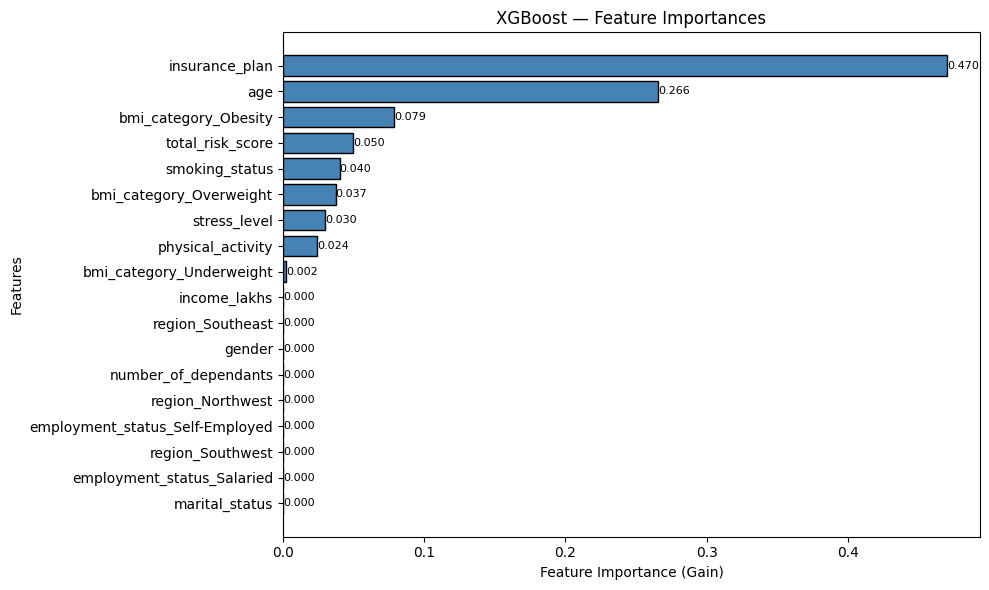

In [36]:
best_model = xgb_search.best_estimator_
coefs = best_model.feature_importances_

try:
    features = X.columns.to_numpy()
except AttributeError:
    features = np.array([f'X{i}' for i in range(len(coefs))])

idx = np.argsort(coefs)
coefs = coefs[idx]
features = features[idx]

plt.figure(figsize=(10, 6))
bars = plt.barh(features, coefs, color='steelblue', edgecolor='black')

for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2,
             f'{width:.3f}', va='center', fontsize=8)

plt.axvline(0)
plt.xlabel("Feature Importance (Gain)")
plt.ylabel("Features")
plt.title("XGBoost — Feature Importances")
plt.tight_layout()
plt.show()

### 13.2 Generate Predictions & Compute Residuals

We run the best model on the held-out test set.

**Residuals** = `predicted - actual`

**Residual percentage** = `(predicted - actual) / actual × 100`  
This normalizes error to be interpretable regardless of premium magnitude.  

> ⚠️ A small epsilon (1e-8) is added to the denominator to avoid division by zero.

In [37]:
y_pred = best_model.predict(X_test)
residuals = y_pred - y_test
epsilon = 1e-8
residuals_pct = residuals * 100 / (y_test + epsilon)

### 13.3 Results DataFrame

In [38]:
results_df = pd.DataFrame({
    'actual': y_test,
    'predicted': y_pred,
    'diff': residuals,
    'diff_pct': residuals_pct
})
results_df.head(10)

,actual,predicted,diff,diff_pct
8712,20716,21256.150391,540.150391,2.607407
1560,9762,8848.505859,-913.494141,-9.357654
1144,6633,5771.246582,-861.753418,-12.991910
3987,32220,32641.146484,421.146484,1.307096
1784,29529,30214.371094,685.371094,2.321010
6549,7730,7672.593750,-57.406250,-0.742642
5324,7888,8675.794922,787.794922,9.987258
8495,35518,34913.261719,-604.738281,-1.702625
2112,29343,30431.812500,1088.812500,3.710638
8865,22974,23462.580078,488.580078,2.126665


### 13.4 Extreme Error Analysis

We define **extreme errors** as predictions where the percentage error exceeds ±10%.  
This is a business-relevant threshold — a premium estimate off by more than 10% would likely be unacceptable to an insurer.

In [39]:
extreme_results = results_df[np.abs(results_df.diff_pct) > 10]
print(f"Extreme errors (>10%)  : {extreme_results.shape[0]}")
print(f"Total test samples     : {X_test.shape[0]}")
print(f"Extreme error rate     : {extreme_results.shape[0] * 100 / results_df.shape[0]:.2f}%")

Extreme errors (>10%)  : 161
Total test samples     : 2972
Extreme error rate     : 5.42%


### 13.5 Error Distribution Plot

A histogram of `diff_pct` with a KDE overlay shows the distribution of prediction errors.  

**What to look for:**
- **Centered at 0** → model has no systematic bias
- **Narrow spread** → most predictions are close to actual
- **Fat tails** → model struggles on certain edge cases

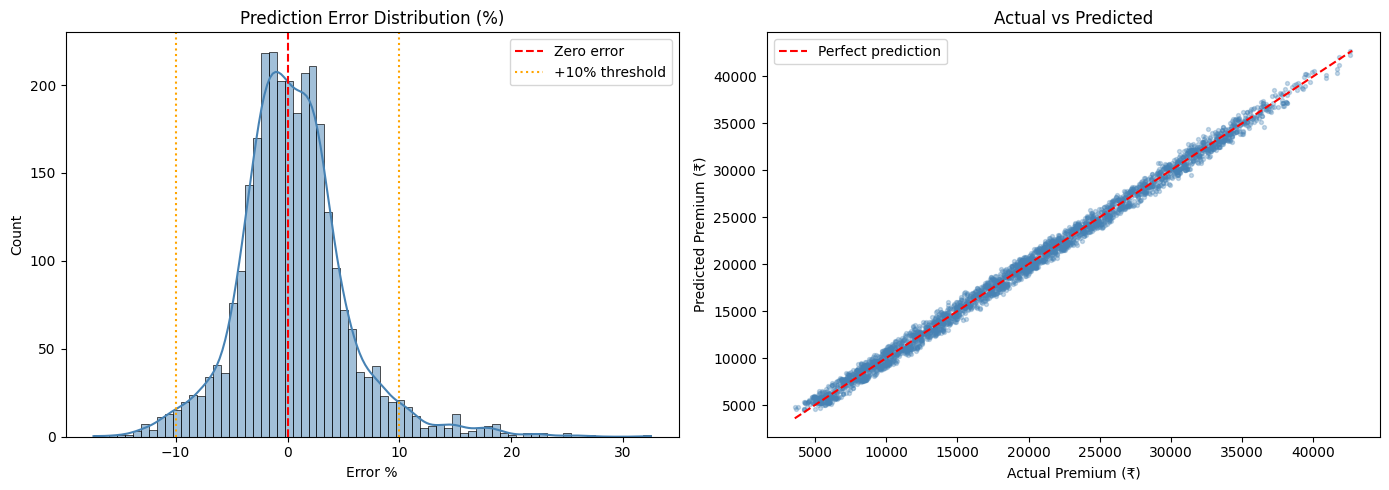

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Error % histogram
sns.histplot(results_df["diff_pct"], kde=True, ax=axes[0], color='steelblue')
axes[0].axvline(0, color='red', linestyle='--', label='Zero error')
axes[0].axvline(10, color='orange', linestyle=':', label='+10% threshold')
axes[0].axvline(-10, color='orange', linestyle=':')
axes[0].set_title("Prediction Error Distribution (%)")
axes[0].set_xlabel("Error %")
axes[0].legend()

# Actual vs Predicted scatter
axes[1].scatter(y_test, y_pred, alpha=0.3, s=8, color='steelblue')
mn, mx = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
axes[1].plot([mn, mx], [mn, mx], 'r--', label='Perfect prediction')
axes[1].set_xlabel("Actual Premium (₹)")
axes[1].set_ylabel("Predicted Premium (₹)")
axes[1].set_title("Actual vs Predicted")
axes[1].legend()

plt.tight_layout()
plt.show()

---
## Section 14 — Saving Artifacts

### 14.1 Save the Model

`joblib.dump()` serializes the trained XGBoost model to disk.  
This allows you to load it later for inference **without retraining**.

```python
# To load later:
from joblib import load
model = load("artifacts/model.joblib")
```

In [41]:
import os
os.makedirs("artifacts", exist_ok=True)
dump(best_model, "artifacts/model.joblib")

['artifacts/model.joblib']

### 14.2 Save the Scaler

Crucially, the **scaler** is saved alongside the model.  
When making a new prediction in production, you must apply the **same scaling** that was used during training, or the model will produce garbage output.

We save both the scaler object and the column names it was fit on (`cols_to_scale`), so the correct columns can be scaled at inference time.

In [42]:
cols_to_scale = X.columns
scaler_with_cols = {
    'scaler': scaler,
    'cols_to_scale': cols_to_scale
}
dump(scaler_with_cols, "artifacts/scaler.joblib")

['artifacts/scaler.joblib']

### 14.3 Final Feature List

The 18 features the model expects at inference time:

In [43]:
print("Final features used by the model:")
for i, col in enumerate(X.columns, 1):
    print(f"  {i:2d}. {col}")

Final features used by the model:
   1. age
   2. gender
   3. marital_status
   4. physical_activity
   5. stress_level
   6. number_of_dependants
   7. smoking_status
   8. income_lakhs
   9. insurance_plan
  10. total_risk_score
  11. region_Northwest
  12. region_Southeast
  13. region_Southwest
  14. bmi_category_Obesity
  15. bmi_category_Overweight
  16. bmi_category_Underweight
  17. employment_status_Salaried
  18. employment_status_Self-Employed


---
## Section 15 — Pipeline Summary

```
Raw Excel Data
    │
    ├── Column Normalization (snake_case)
    ├── Drop NaN rows (~34 rows)
    ├── Outlier Removal (age > 100, income > 100L)
    ├── Drop redundant column (income_level)
    │
    ├── Ordinal Encoding (gender, marital_status, physical_activity,
    │                     stress_level, smoking_status, insurance_plan)
    ├── Feature Engineering (medical_history → total_risk_score)
    ├── One-Hot Encoding (region, bmi_category, employment_status)
    ├── StandardScaler → X (18 features)
    ├── VIF Check (all < 2.5 — no multicollinearity)
    │
    ├── Train/Test Split (70/30)
    │
    ├── Linear Regression  (baseline)
    ├── Ridge Regression   (L2 regularization)
    ├── Random Forest      (RandomizedSearchCV, 10 iterations)
    └── XGBoost ✓ BEST     (RandomizedSearchCV, 15 iterations)
            │
            ├── Feature Importance Plot
            ├── Residual Analysis (diff_pct)
            ├── Extreme Error Rate (>10% threshold)
            │
            ├── artifacts/model.joblib   ← saved model
            └── artifacts/scaler.joblib  ← saved scaler + column names
```